In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [14]:
# Load dataset
df = pd.read_csv("../../Final_data/KO.csv")

# Display first 5 rows
df.head()

,Date,Volume,Open,High,Low,Close,Adj close,Sentiment_gpt,News_flag,Scaled_sentiment
0,2009-10-14 00:00:00+00:00,16081000.0,27.459999,27.514999,27.295000,27.420000,18.121803,2.0,1.0,0.250025
1,2009-10-15 00:00:00+00:00,24241800.0,27.365000,27.605000,27.174999,27.459999,18.148237,3.0,1.0,0.500025
2,2009-10-16 00:00:00+00:00,22090800.0,27.459999,27.600000,27.344999,27.504999,18.177977,3.0,0.0,0.500025
3,2009-10-19 00:00:00+00:00,20656000.0,27.570000,27.750000,27.334999,27.395000,18.105282,3.0,0.0,0.500025
4,2009-10-20 00:00:00+00:00,26859600.0,26.795000,27.075001,26.590000,27.035000,17.867361,3.0,0.0,0.500025


In [15]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [16]:
# Target
y = df['Close']

# Exogenous features (YOU CAN MODIFY THIS)
df['lag5'] = df['Close'].shift(5)

# Drop NaN after feature creation
df = df.dropna()

# Define X and y again after dropna
y = df['Close']
X = df[['Volume', 'lag5']]

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y)
print(result[1])  # p-value

0.4844149628121132


In [18]:
y_diff = y.diff().dropna()

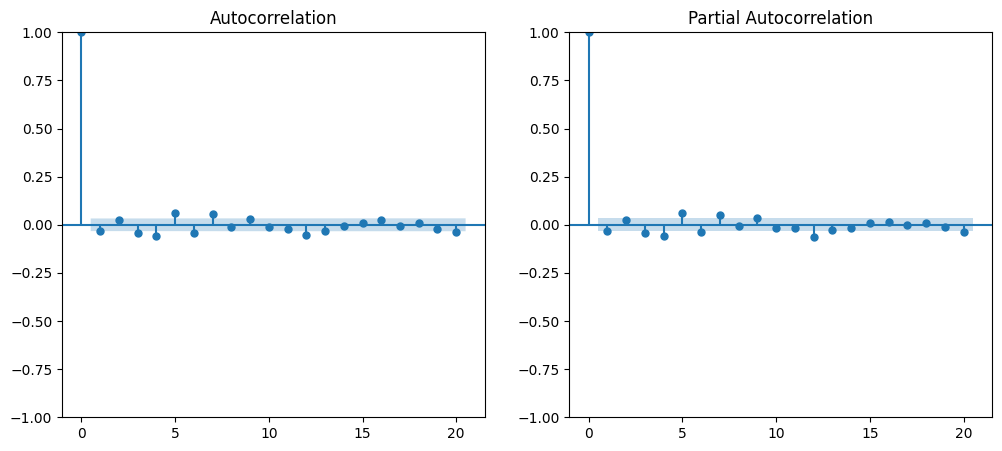

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(y_diff, ax=plt.gca(), lags=20)

plt.subplot(1,2,2)
plot_pacf(y_diff, ax=plt.gca(), lags=20)

plt.show()

In [20]:
n = len(df)

train_size = int(n * 0.7)
val_size = int(n * 0.15)

y_train = y[:train_size]
y_val = y[train_size:train_size + val_size]
y_test = y[train_size + val_size:]

X_train = X[:train_size]
X_val = X[train_size:train_size + val_size]
X_test = X[train_size + val_size:]

In [21]:
def evaluate_arimax(train, val, exog_train, exog_val, order):
    
    model = SARIMAX(
        train,
        exog=exog_train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    model_fit = model.fit(disp=False)
    
    forecast = model_fit.forecast(
        steps=len(val),
        exog=exog_val
    )
    
    forecast = pd.Series(forecast)

# Align length safely
    forecast.index = val.index[:len(forecast)] 
       
    df_eval = pd.concat([val, forecast], axis=1)
    df_eval.columns = ['actual', 'pred']
    df_eval = df_eval.dropna()
    
    mae = mean_absolute_error(df_eval['actual'], df_eval['pred'])
    rmse = np.sqrt(mean_squared_error(df_eval['actual'], df_eval['pred']))
    r2 = r2_score(df_eval['actual'], df_eval['pred'])
    
    return mae, rmse, r2, model_fit, df_eval

In [22]:
orders = [(0,1,0), (1,1,0), (0,1,1), (0,1,2), (1,1,2), (2,1,2)]

results = []

for order in orders:
    mae, rmse, r2, model_fit, df_eval = evaluate_arimax(
        y_train, y_val, X_train, X_val, order
    )
    
    print(f"Order {order} → MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
    results.append((order, mae, rmse, r2))

Order (0, 1, 0) → MAE: 3.3911, RMSE: 4.5853, R2: -0.3183
Order (1, 1, 0) → MAE: 3.3914, RMSE: 4.5857, R2: -0.3185
Order (0, 1, 1) → MAE: 3.3913, RMSE: 4.5855, R2: -0.3184
Order (0, 1, 2) → MAE: 3.3887, RMSE: 4.5818, R2: -0.3163
Order (1, 1, 2) → MAE: 3.3956, RMSE: 4.5917, R2: -0.3220
Order (2, 1, 2) → MAE: 3.3980, RMSE: 4.5950, R2: -0.3239


In [23]:
import pandas as pd

# Your results list already exists like:
# results = [(order, mae, rmse, r2), ...]

results_df = pd.DataFrame(results, columns=['Order', 'MAE', 'RMSE', 'R2'])

# Sort by RMSE (best model on top)
results_df = results_df.sort_values(by='RMSE')

results_df.style.format({
    'MAE': "{:.4f}",
    'RMSE': "{:.4f}",
    'R2': "{:.4f}"
})

,Order,MAE,RMSE,R2
3,"(0, 1, 2)",3.3887,4.5818,-0.3163
0,"(0, 1, 0)",3.3911,4.5853,-0.3183
2,"(0, 1, 1)",3.3913,4.5855,-0.3184
1,"(1, 1, 0)",3.3914,4.5857,-0.3185
4,"(1, 1, 2)",3.3956,4.5917,-0.3220
5,"(2, 1, 2)",3.3980,4.5950,-0.3239


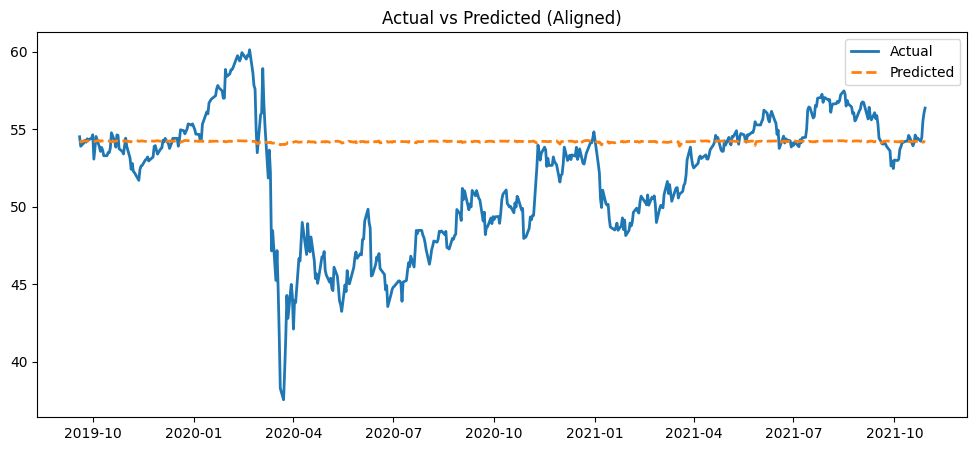

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df_eval['actual'], label='Actual', linewidth=2)
plt.plot(df_eval['pred'], label='Predicted', linestyle='--', linewidth=2)

plt.legend()
plt.title('Actual vs Predicted (Aligned)')
plt.show()